# Semana 4: Filas

En la siguiente celda de código se incluye el script correspondiente al **Fragametno de Código 6.6 y 6.7**.

In [1]:
class Empty(Exception):
    pass

class ArrayQueue:
    """FIFO queue implementation using a Python list as underlying storage."""
    DEFAULT_CAPACITY = 10  # moderate capacity for all new queues

    def __init__(self):
        """Create an empty queue."""
        self._data = [None] * ArrayQueue.DEFAULT_CAPACITY
        self._size = 0
        self._front = 0

    def __len__(self):
        """Return the number of elements in the queue."""
        return self._size

    def is_empty(self):
        """Return True if the queue is empty."""
        return self._size == 0

    def first(self):
        """Return (but do not remove) the element at the front of the queue.
        Raise Empty exception if the queue is empty.
        """
        if self.is_empty():
            raise Empty('Queue is empty')
        return self._data[self._front]

    def dequeue(self):
        """Remove and return the first element of the queue (i.e., FIFO).
        Raise Empty exception if the queue is empty.
        """
        if self.is_empty():
            raise Empty('Queue is empty')
        answer = self._data[self._front]
        self._data[self._front] = None          # help garbage collection
        self._front = (self._front + 1) % len(self._data)
        self._size -= 1
        return answer

    def enqueue(self, e):
        """Add an element to the back of queue."""
        if self._size == len(self._data):
            self._resize(2 * len(self._data))   # double the array size
        avail = (self._front + self._size) % len(self._data)
        self._data[avail] = e
        self._size += 1

    def _resize(self, cap):
        """Resize to a new list of capacity >= len(self)."""
        old = self._data                         # keep track of existing list
        self._data = [None] * cap                # allocate list with new capacity
        walk = self._front
        for k in range(self._size):              # only consider existing elements
            self._data[k] = old[walk]            # intentionally shift indices
            walk = (walk + 1) % len(old)        # use old size as modulus
        self._front = 0                          # front has been
        

**R-6.7** What values are returned during the following sequence of queue operations, if executed on an initially empty queue? enqueue(5), enqueue(3), dequeue(), enqueue(2), enqueue(8), dequeue(), dequeue(), enqueue(9), enqueue(1), dequeue(), enqueue(7), enqueue(6), dequeue(), dequeue(), enqueue(4), dequeue(), dequeue().

| Instrucción | Valor devuelto | Estado del arreglo (Cola) |
| --- | --- | --- |
| `enqueue(5)` | - | [5] |
| `enqueue(3)` | - |[5,3]  |
| `dequeue()` | 5 | [3] |
| `enqueue(2)` |-  | [3,2] |
| `enqueue(8)` | - |[3,2,8]  |
| `dequeue()` | 3 | [2,8] |
| `dequeue()` | 2 | [8] |
| `enqueue(9)` | - |[8,9]  |
| `enqueue(1)` | - | [8,9,1] |
| `dequeue()` | 8 | [9,1] |
| `enqueue(7)` | - | [9,1,7] |
| `enqueue(6)` | - |[9,1,7,6]  |
| `dequeue()` | 9 | [1,7,6] |
| `dequeue()` | 1 | [7,6] |
| `enqueue(4)` | - |  [7,6,4]|
| `dequeue()` | 7 | [6,4] |
| `dequeue()` | 6 | [4] |

**R-6.8** Suppose an initially empty queue $Q$ has executed a total of 32 enqueue operations, 10 first operations, and 15 dequeue operations, 5 of which raised Empty errors that were caught and ignored. What is the current size of $Q$?

El tamaño actual de Q es de 22.

**R-6.10** Consider what happens if the loop in the ArrayQueue._resize method at lines 53–55 of Code Fragment 6.7 had been implemented as:

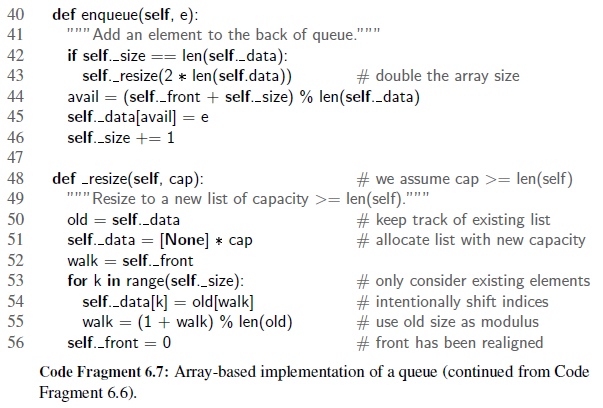

In [2]:
class Empty(Exception):
    pass

class ArrayQueue:
    """FIFO queue implementation using a Python list as underlying storage."""
    DEFAULT_CAPACITY = 5 # moderate capacity for all new queues

    def __init__(self):
        """Create an empty queue."""
        self._data = [None] * ArrayQueue.DEFAULT_CAPACITY
        self._size = 0
        self._front = 0

    def __len__(self):
        """Return the number of elements in the queue."""
        return self._size

    def is_empty(self):
        """Return True if the queue is empty."""
        return self._size == 0

    def first(self):
        """Return (but do not remove) the element at the front of the queue.
        Raise Empty exception if the queue is empty.
        """
        if self.is_empty():
            raise Empty('Queue is empty')
        return self._data[self._front]

    def dequeue(self):
        """Remove and return the first element of the queue (i.e., FIFO).
        Raise Empty exception if the queue is empty.
        """
        if self.is_empty():
            raise Empty('Queue is empty')
        answer = self._data[self._front]
        self._data[self._front] = None          # help garbage collection
        self._front = (self._front + 1) % len(self._data)
        self._size -= 1
        return answer

    def enqueue(self, e):
        """Add an element to the back of queue."""
        if self._size == len(self._data):
            self._resize(2 * len(self._data))   # double the array size
        avail = (self._front + self._size) % len(self._data)
        self._data[avail] = e
        self._size += 1

    def _resize(self, cap):
        """Resize to a new list of capacity >= len(self)."""
        old = self._data                         # keep track of existing list
        self._data = [None] * cap                # allocate list with new capacity
        walk = self._front
        for k in range(self._size):
            self._data[k] = old[k]    # rather than old[walk]
        self._front = 0                          # front has been
    def _mostrar(self):
        return self._data 
    def _mostrarFront(self):
        return self._front
Q2 = ArrayQueue()
for i in range(1,6):
    Q2.enqueue(i)
print("Q2 inicial: ", Q2._mostrar())
Q2.dequeue()
Q2.enqueue(11)
Q2.enqueue(22)
print("Q2 final: ", Q2._mostrar())
print("El front debería ser la posición 1, pero el front actual es: ", Q2._mostrarFront())

Q2 inicial:  [1, 2, 3, 4, 5]
Q2 final:  [11, 2, 3, 4, 5, 22, None, None, None, None]
El front debería ser la posición 1, pero el front actual es:  0


El código de arriba muestra la falla que ocurre si se usa _resize() con el for dado en el ejercicio que no considera al front, al no considerarse, al moverse la lista, el front se mueve a la posición 0 cuando (por operaciones anteriores como dequeue()) el front era el valor dos que se encuentra en la posición 1. 

Give a clear explanation of what could go wrong.

Si se implementara el código propuesto en lugar del original, la cola se copiaría de manera errónea, ya que no contempla la posición actual de front y transfiere los elementos siguiendo un orden lineal simple. En los casos donde la cola que llama a _resize() tenga su front en el índice 0, el bucle for que utiliza únicamente k copiará los elementos correctamente. Sin embargo, en cualquier otro caso donde front no se encuentre en la posición inicial (debido al comportamiento circular del arreglo), la lista copiará elementos fuera del orden lógico correspondiente. Luego, al actualizar self._front = 0 al finalizar el bucle, se romperá la estructura y el funcionamiento FIFO (First In, First Out) dejará de cumplirse al operar con la cola.

**R-6.12** What values are returned during the following sequence of deque ADT operations, on initially empty deque? add_first(4), add_last(8), add_last(9), add_first(5), back(), delete_first(), delete_last(), add_last(7), first(), last(), add_last(6), delete_first(), delete_last().

| Instrucción | Valor devuelto | Estado del deque (Fila) |
| --- | --- | --- |
| `add_first(4)` |-  | [4] |
| `add_last(8)` | - | [4,8] |
| `add_last(9)` | - | [4,8,9] |
| `add_first(5)` | - | [5,4,8,9] |
| `last()` | 9 | [5,4,8,9] |
| `delete_first()` | 5 | [4,8,9] |
| `delete_last()` | 9 | [4,8] |
| `add_last(7)` | - | [4,8,7] |
| `first()` | 4 | [4,8,7] |
| `last()` | 7 | [4,8,7] |
| `add_last(6)` | - | [4,8,7,6] |
| `delete_first()` | 4 | [8,7,6] |
| `delete_last()` | 6 | [8,7] |

**R-6.13** Suppose you have a deque $D$ containing the numbers (1, 2, 3, 4, 5, 6, 7, 8), in this order. Suppose further that you have an initially empty queue $Q$. Give a code fragment that uses only $D$ and $Q$ (and no other variables) and results in $D$ storing the elements in the order (1, 2, 3, 5, 4, 6, 7, 8).

In [3]:
class Empty(Exception):
    pass

class ArrayDeque:
    """FIFO queue implementation using a Python list as underlying storage."""
    DEFAULT_CAPACITY = 8  # moderate capacity for all new queues

    def __init__(self):
        """Create an empty queue."""
        self._data = [None] * ArrayDeque.DEFAULT_CAPACITY
        self._size = 0
        self._front = 0

    def __len__(self):
        """Return the number of elements in the queue."""
        return self._size

    def is_empty(self):
        """Return True if the queue is empty."""
        return self._size == 0

    def first(self):
        """Return (but do not remove) the element at the front of the deque.
        Raise Empty exception if the queue is empty.
        """
        if self.is_empty():
            raise Empty('Deque is empty')
        return self._data[self._front]
    
    def last(self):
        """Return (but do not remove) the last element on deque.
        Raise Empty exception if the queue is empty.
        """
        if self.is_empty():
            raise Empty('Deque is empty')
        last = (self._front + self._size-1) % len(self._data)
        return self._data[last]

    def delete_first(self):
        """Remove and return the first element of the deque (i.e., FIFO).
        Raise Empty exception if the queue is empty.
        """
        if self.is_empty():
            raise Empty('Deque is empty')
        answer = self._data[self._front]
        self._data[self._front] = None          # help garbage collection
        self._front = (self._front + 1) % len(self._data)
        self._size -= 1
        return answer

    def delete_last(self):
        """Remove and return the last element of the deque (i.e., FIFO).
        Raise Empty exception if the queue is empty.
        """
        if self.is_empty():
            raise Empty('Deque is empty')
        last = (self._front + self._size - 1) % len(self._data)
        answer = self._data[last]
        self._data[last] = None          # help garbage collection
        self._size -= 1
        return answer

    def add_last(self, e):
        """Add an element to the back of deque."""
        if self._size == len(self._data):
            self._resize(2 * len(self._data))   # double the array size
        avail = (self._front + self._size) % len(self._data)
        self._data[avail] = e
        self._size += 1
    
    def add_first(self, e):
        """Add an element first on deque."""
        if self._size == len(self._data):
            self._resize(2 * len(self._data))   # double the array size
        self._front = (self._front - 1) % len(self._data)
        self._data[self._front] = e
        self._size += 1

    def _resize(self, cap):
        """Resize to a new list of capacity >= len(self)."""
        old = self._data                         # keep track of existing list
        self._data = [None] * cap                # allocate list with new capacity
        walk = self._front
        for k in range(self._size):              # only consider existing elements
            self._data[k] = old[walk]            # intentionally shift indices
            walk = (walk + 1) % len(old)        # use old size as modulus
        self._front = 0                          # front has been
    def _mostrar(self):
        print(self._data)
    
    def __getitem__(self, k):
        if not 0 <= k < self._size:
            raise IndexError('Índice fuera de rango')
        index = (self._front + k) % len(self._data)
        return self._data[index]

class Empty(Exception):
    pass

class ArrayQueue:
    """FIFO queue implementation using a Python list as underlying storage."""
    DEFAULT_CAPACITY = 8  # moderate capacity for all new queues

    def __init__(self):
        """Create an empty queue."""
        self._data = [None] * ArrayQueue.DEFAULT_CAPACITY
        self._size = 0
        self._front = 0

    def __len__(self):
        """Return the number of elements in the queue."""
        return self._size

    def is_empty(self):
        """Return True if the queue is empty."""
        return self._size == 0

    def first(self):
        """Return (but do not remove) the element at the front of the queue.
        Raise Empty exception if the queue is empty.
        """
        if self.is_empty():
            raise Empty('Queue is empty')
        return self._data[self._front]

    def dequeue(self):
        """Remove and return the first element of the queue (i.e., FIFO).
        Raise Empty exception if the queue is empty.
        """
        if self.is_empty():
            raise Empty('Queue is empty')
        answer = self._data[self._front]
        self._data[self._front] = None          # help garbage collection
        self._front = (self._front + 1) % len(self._data)
        self._size -= 1
        return answer

    def enqueue(self, e):
        """Add an element to the back of queue."""
        if self._size == len(self._data):
            self._resize(2 * len(self._data))   # double the array size
        avail = (self._front + self._size) % len(self._data)
        self._data[avail] = e
        self._size += 1

    def _resize(self, cap):
        """Resize to a new list of capacity >= len(self)."""
        old = self._data                         # keep track of existing list
        self._data = [None] * cap                # allocate list with new capacity
        walk = self._front
        for k in range(self._size):              # only consider existing elements
            self._data[k] = old[walk]            # intentionally shift indices
            walk = (walk + 1) % len(old)        # use old size as modulus
        self._front = 0                          # front has been
    def _mostrar(self):
        print(self._data) 
    def __getitem__(self, k):
        if not 0 <= k < self._size:
            raise IndexError('Índice fuera de rango')
        index = (self._front + k) % len(self._data)
        return self._data[index]
        
D = ArrayDeque()
Q = ArrayQueue()
for k in range (1,9):
    D.add_last(k)
print("Q inicial: ")
Q._mostrar()
print("\nD inicial: ")
D._mostrar()
Q.enqueue(D.delete_first())
Q.enqueue(D.delete_first())
Q.enqueue(D.delete_first()) #[1,2,3]

D.add_last(D.delete_first()) #[5,6,7,8,4]

Q.enqueue(D.delete_first()) #[1,2,3,5]
Q.enqueue(D.delete_last()) #[1,2,3,5,4]

Q.enqueue(D.delete_first())
Q.enqueue(D.delete_first())
Q.enqueue(D.delete_first()) #[1,2,3,5,4,6,7,8]

while not Q.is_empty():
    D.add_last(Q.dequeue())
print("\nD final:")
D._mostrar()

Q inicial: 
[None, None, None, None, None, None, None, None]

D inicial: 
[1, 2, 3, 4, 5, 6, 7, 8]

D final:
[1, 2, 3, 5, 4, 6, 7, 8]


Este código implementa dos estructuras de datos circulares (ArrayQueue para flujo estándar FIFO y ArrayDeque para insertar/eliminar por ambos extremos) y utiliza una rutina externa para reordenar una secuencia de números, llena el deque con los valores del 1 al 8, pasa datos temporalmente a la cola (en este caso el 4 se paso al final) alternando extracciones e inserciones en los extremos (lo que invierte únicamente el orden del 4 y el 5), y finalmente regresa todo al deque para obtener la lista final reorganizada como [1, 2, 3, 5, 4, 6, 7, 8]. La clase ArrayDeque se obtuvo al modificar la clase ArrayQueue dada en la tarea.

In [ ]:
for k in range (1,9):
    D.add_last(k)
print("Q inicial: ")
Q._mostrar()
print("D inicial: ")
D._mostrar()
for k in range(8):
    if k == 3:
        pass
    else:
        Q.enqueue(D[k])
Q.enqueue(D[3])
print("Copia de D -> Q= ")
Q._mostrar()
for k in range(8):
    D.delete_first()
print("D vacia para recibir a Q: ")
D._mostrar()
for k in range(4):
    D.add_last(Q[k])
D.add_last(Q[7])
for k in range(4,7):
    D.add_last(Q[k])
print("D final:")
D._mostrar()

Q inicial: 
[None, None, None, None, None, None, None, None]
D inicial: 
[1, 2, 3, 5, 4, 6, 7, 8, 1, 2, 3, 4, 5, 6, 7, 8]
Copia de D -> Q= 
[1, 2, 3, 4, 6, 7, 8, 5]
D vacia para recibir a Q: 
[None, None, None, None, None, None, None, None, 1, 2, 3, 4, 5, 6, 7, 8]
D final:
[1, 2, 3, 4, 5, 6, 7, 8, 1, 2, 3, 4, 5, 6, 7, 8]


**R-6.14** Repeat the previous problem using the deque $D$ and an initially empty stack $S$.

In [4]:
class Empty(Exception):
    """Error attempting to access an element from an empty container."""
    pass

class ArrayStack:
    """LIFO Stack implementation using a Python list as underlying storage."""

    def __init__(self):
        """Create an empty stack."""
        self._data = []  # nonpublic list instance

    def __len__(self):
        """Return the number of elements in the stack."""
        return len(self._data)

    def is_empty(self):
        """Return True if the stack is empty."""
        return len(self._data) == 0

    def push(self, e):
        """Add element e to the top of the stack."""
        self._data.append(e)  # new item stored at end of list

    def top(self):
        """Return (but do not remove) the element at the top of the stack.
        Raise Empty exception if the stack is empty.
        """
        if self.is_empty():
            raise Empty('Stack is empty')
        return self._data[-1]  # the last item in the list

    def pop(self):
        """Remove and return the element from the top of the stack (i.e., LIFO).
        Raise Empty exception if the stack is empty.
        """
        if self.is_empty():
            raise Empty('Stack is empty')
        return self._data.pop()  # remove last
    
    def remove(self):
        if self.is_empty():
            print("stack is empty")
            return self
        else:
            self.pop()
            return self.remove()
    def _mostrar(self):
        print(self._data)

class ArrayDeque:
    """FIFO queue implementation using a Python list as underlying storage."""
    DEFAULT_CAPACITY = 8  # moderate capacity for all new queues

    def __init__(self):
        """Create an empty queue."""
        self._data = [None] * ArrayDeque.DEFAULT_CAPACITY
        self._size = 0
        self._front = 0

    def __len__(self):
        """Return the number of elements in the queue."""
        return self._size

    def is_empty(self):
        """Return True if the queue is empty."""
        return self._size == 0

    def first(self):
        """Return (but do not remove) the element at the front of the deque.
        Raise Empty exception if the queue is empty.
        """
        if self.is_empty():
            raise Empty('Deque is empty')
        return self._data[self._front]
    
    def last(self):
        """Return (but do not remove) the last element on deque.
        Raise Empty exception if the queue is empty.
        """
        if self.is_empty():
            raise Empty('Deque is empty')
        last = (self._front + self._size-1) % len(self._data)
        return self._data[last]
    
    def delete_first(self):
        """Remove and return the first element of the deque (i.e., FIFO).
        Raise Empty exception if the queue is empty.
        """
        if self.is_empty():
            raise Empty('Deque is empty')
        answer = self._data[self._front]
        self._data[self._front] = None          # help garbage collection
        self._front = (self._front + 1) % len(self._data)
        self._size -= 1
        return answer

    def delete_last(self):
        """Remove and return the last element of the deque (i.e., FIFO).
        Raise Empty exception if the queue is empty.
        """
        if self.is_empty():
            raise Empty('Deque is empty')
        last = (self._front + self._size - 1) % len(self._data)
        answer = self._data[last]
        self._data[last] = None          # help garbage collection
        self._size -= 1
        return answer

    def add_last(self, e):
        """Add an element to the back of deque."""
        if self._size == len(self._data):
            self._resize(2 * len(self._data))   # double the array size
        avail = (self._front + self._size) % len(self._data)
        self._data[avail] = e
        self._size += 1
    
    def add_first(self, e):
        """Add an element first on deque."""
        if self._size == len(self._data):
            self._resize(2 * len(self._data))   # double the array size
        self._front = (self._front - 1) % len(self._data)
        self._data[self._front] = e
        self._size += 1

    def _resize(self, cap):
        """Resize to a new list of capacity >= len(self)."""
        old = self._data                         # keep track of existing list
        self._data = [None] * cap                # allocate list with new capacity
        walk = self._front
        for k in range(self._size):              # only consider existing elements
            self._data[k] = old[walk]            # intentionally shift indices
            walk = (walk + 1) % len(old)        # use old size as modulus
        self._front = 0                          # front has been
    def _mostrar(self):
        print(self._data)
    
    def __getitem__(self, k):
        if not 0 <= k < self._size:
            raise IndexError('Índice fuera de rango')
        index = (self._front + k) % len(self._data)
        return self._data[index]
D = ArrayDeque()
S = ArrayStack()
for k in range (1,9):
    D.add_last(k)
print("S inicial: ")
S._mostrar()
print("\nD inicial: ")

D._mostrar()
S.push(D.delete_last())
S.push(D.delete_last())
S.push(D.delete_last())
S.push(D.delete_last()) #[8, 7, 6, 5]

D.add_first(D.delete_last()) #[1, 2, 3, None, None, None, None, 4]

S.push(D.delete_last())
S.push(D.delete_last())
S.push(D.delete_last())
S.push(D.delete_first())
print("\nS copiada de D:")
S._mostrar()

D.add_first(S.pop()) #[1, None, None, None, None, None, None, 4]
D.add_last(S.pop())
D.add_last(S.pop())
D.add_last(S.pop())
D.add_last(S.pop())
D.add_last(D.delete_first()) #Cambio de posición de 4, todo dentro de D
D.add_last(S.pop())
D.add_last(S.pop())
D.add_last(S.top())
S.pop()

print("\nD final:")
D._mostrar()
print("\nS final:")
S._mostrar()

S inicial: 
[]

D inicial: 
[1, 2, 3, 4, 5, 6, 7, 8]

S copiada de D:
[8, 7, 6, 5, 3, 2, 1, 4]

D final:
[1, 2, 3, 5, 4, 6, 7, 8]

S final:
[]


Este código define una pila (ArrayStack, LIFO) y una cola doble (ArrayDeque, circular), utilizando una rutina externa para invertir y modificar el orden de la secuencia del 1 al 8, tras llenar el deque con los 8 números, extrae sus elementos por ambos extremos para apilarlos temporalmente en la pila (lo que invierte su orden natural), luego devuelve los datos al deque intercalando algunas operaciones de reordenamiento de posiciones (como mover el número 4) y finalmente vacía la pila, dejando el deque con la secuencia alterada [1, 2, 3, 5, 6, 7, 8, 4] y la pila completamente vacía.